# **EXPERIMENT-2** -Titanic Dataset

In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Datasets/Titanic.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
print("Shape of the Dataset:",df.shape)
print("No.of columns in the dataset:",df.columns)

Shape of the Dataset: (1309, 28)
No.of columns in the dataset: Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')


In [ ]:
#Drop unnecessary columns
cols_to_drop = ['Passengerid'] + [col for col in df.columns if 'zero' in col]
df = df.drop(columns=cols_to_drop)
df.shape
df.columns


Index(['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked',
       '2urvived'],
      dtype='object')

In [ ]:
#Check duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
df.shape


Duplicate rows: 209


(1100, 8)

In [ ]:
# Check missing values
df.isna().sum()

,0
Age,0
Fare,0
Sex,0
sibsp,0
Parch,0
Pclass,0
Embarked,2
2urvived,0


In [ ]:
df1=df.copy()
# Encode categorical columns
s = preprocessing.LabelEncoder()
df1['Sex'] = s.fit_transform(df1['Sex'])

emb = preprocessing.LabelEncoder()
df1['Embarked'] = emb.fit_transform(df1['Embarked'])

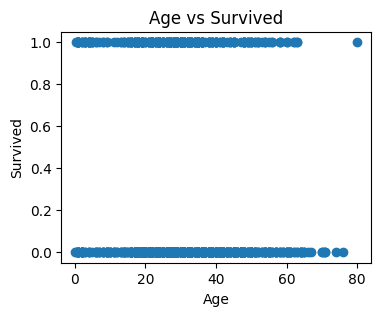

In [ ]:
# Scatter plots
plt.figure(figsize=(4,3))
plt.scatter(df1['Age'], df1['2urvived'])
plt.xlabel('Age')
plt.ylabel('Survived')
plt.title('Age vs Survived')
plt.show()

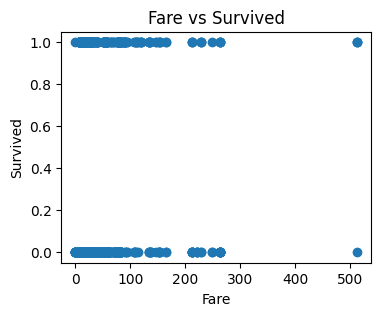

In [ ]:
plt.figure(figsize=(4,3))
plt.scatter(df1['Fare'], df1['2urvived'])
plt.xlabel('Fare')
plt.ylabel('Survived')
plt.title('Fare vs Survived')
plt.show()

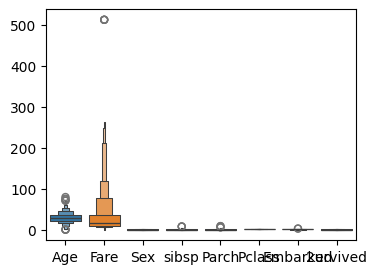

In [ ]:
#Boxplots to detect outliers
plt.figure(figsize=(4,3))
sns.boxenplot(df1)
plt.show()

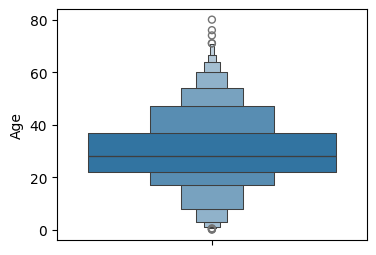

In [ ]:
plt.figure(figsize=(4,3))
sns.boxenplot(df1['Age'])
plt.show()

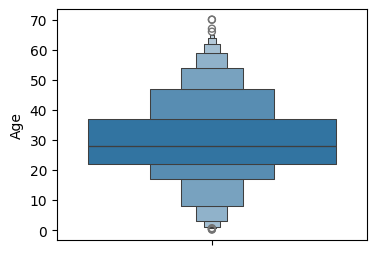

In [ ]:
df2= df1.loc[df['Age']<=70]
plt.figure(figsize=(4,3))
sns.boxenplot(df2['Age'])
plt.show()

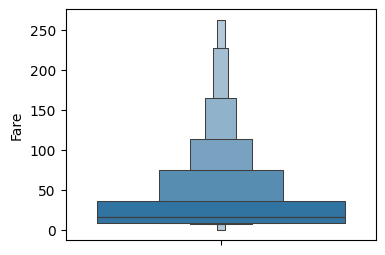

In [ ]:
df3 = df1.loc[df['Fare'] <500]
plt.figure(figsize=(4,3))
sns.boxenplot(df3['Fare'])
plt.show()

In [ ]:
df3.shape
# Feature-target split
X = df3.drop(columns=['2urvived'])
Y = df3[['2urvived']]

In [ ]:
#Train-test split
train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=0.3,random_state=42)
train_x.shape, test_x.shape, train_y.shape, test_y.shape

((767, 7), (329, 7), (767, 1), (329, 1))

In [ ]:
train_x.head(2)

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked
676,24.5,8.05,0,0,0,3,2
331,45.5,28.50,0,0,0,1,2


In [ ]:
train_y.head(2)

,2urvived
676,0
331,0
